Model coefficients:
Attendance coefficient: 0.466
Internal_marks coefficient: 0.455
Activity_marks coefficient: 0.463
Intercept: -11.030


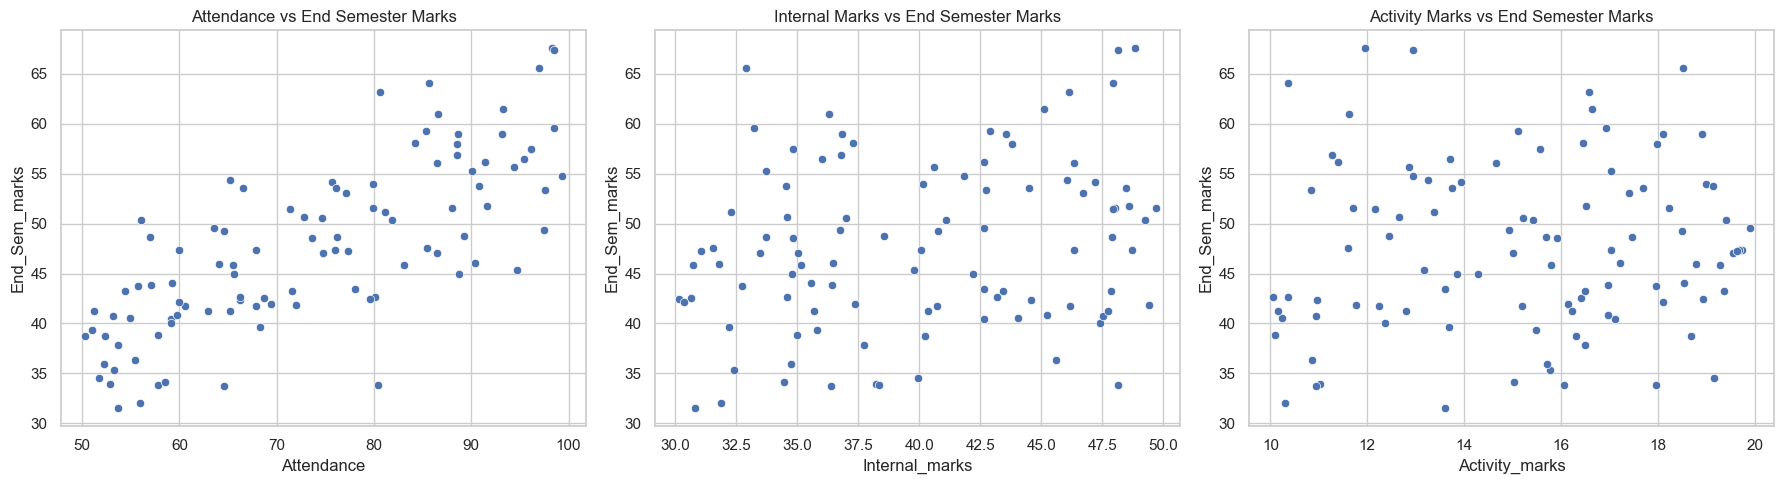

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Simulate dataset
n = 100
Attendance = np.random.uniform(50, 100, n)          # Attendance in percentage (50% to 100%)
Internal_marks = np.random.uniform(30, 50, n)      # Internal marks out of 50
Activity_marks = np.random.uniform(10, 20, n)      # Activity marks out of 20

# Create dependent variable End_Sem_marks based on some relationship + noise
End_Sem_marks = (0.4 * Attendance) + (0.35 * Internal_marks) + (0.25 * Activity_marks) + np.random.normal(0, 5, n)

# Create DataFrame
df = pd.DataFrame({
    'Attendance': Attendance,
    'Internal_marks': Internal_marks,
    'Activity_marks': Activity_marks,
    'End_Sem_marks': End_Sem_marks
})

# Split dataset
X = df[['Attendance', 'Internal_marks', 'Activity_marks']]
y = df['End_Sem_marks']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model coefficients:")
print(f"Attendance coefficient: {model.coef_[0]:.3f}")
print(f"Internal_marks coefficient: {model.coef_[1]:.3f}")
print(f"Activity_marks coefficient: {model.coef_[2]:.3f}")
print(f"Intercept: {model.intercept_:.3f}")

def predict_end_sem_marks(attendance, internal_marks, activity_marks):
    """
    Predict the End Semester marks given attendance, internal marks and activity marks.
    """
    features = np.array([[attendance, internal_marks, activity_marks]])
    predicted_marks = model.predict(features)
    return predicted_marks[0]

# Plot settings
sns.set(style='whitegrid')

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Attendance vs End_Sem_marks
sns.scatterplot(x='Attendance', y='End_Sem_marks', data=df, ax=axs[0])
axs[0].set_title('Attendance vs End Semester Marks')

# Internal_marks vs End_Sem_marks
sns.scatterplot(x='Internal_marks', y='End_Sem_marks', data=df, ax=axs[1])
axs[1].set_title('Internal Marks vs End Semester Marks')

# Activity_marks vs End_Sem_marks
sns.scatterplot(x='Activity_marks', y='End_Sem_marks', data=df, ax=axs[2])
axs[2].set_title('Activity Marks vs End Semester Marks')

plt.tight_layout()
plt.show()
